### TYPE YOUR NAME HERE Conor Murray

# ISM 5136 - Data Analytics and Mining for Business

## Lab Session: Classification with Decision Trees

### Overview:
This lab covers operations related to decision tree classification.

### Task:
The code cells in this notebook have been left blank. Your task is to complete these cells and provide the execution results. The corresponding question text for each code cell is provided above the cell. 

### Important: Do <u>not</u> forget to run the cells before submitting your work.


### Data Description:
![Image of Pikachu](https://i.imgur.com/xx8TtMh.png?1) <br>
<b>This is a Pokemon data set. Gotta Catch 'Em All!</b> <br>
The training data ("pokemon_train.csv") includes a number of pokemon and their stats and characteristics. The target attribute that we are trying to predict is "hasMegaEvolution" - i.e., whether a Pokemon is capable of mega evolving or not. <br>
The prediction data ("pokemon_predict.csv") is in similar format, but has missing values for the "hasMegaEvolution" attribute.


### Please note that there are multiple steps under each question. You should complete and run each step individually (before moving on to the next one) to make sure that your code is correct.

### Question 1: Building a Model with Only Numerical Attributes

#### 1.1. Data import and cleaning
* Import the 'pokemon_train.csv' data as a Pandas dataframe.
* Check if there are any missing values in the data. Notice that there are missing values in one of the attributes. Count how many observations have missing values for this attribute.
* Since the number of missing values is high, it might not be a good idea to remove the observations with missing values (this would result in significant data loss). Instead, remove the attribute with missing values attribute from the dataframe. 
* In addition, remove the "Name" attribute since this is a unique identifier that has no prediction value.

In [4]:
import pandas as pd
df = pd.read_csv('pokemon_train.csv')
print(df.isnull().sum())
df = df.drop(columns=['Type_2']) 
df = df.drop(columns=['Name'])
print(df.isnull().sum())

Name                  0
Type_1                0
Type_2              370
HP                    0
Attack                0
Defense               0
Speed                 0
isLegendary           0
Color                 0
Egg_Group_1           0
hasMegaEvolution      0
dtype: int64
Type_1              0
HP                  0
Attack              0
Defense             0
Speed               0
isLegendary         0
Color               0
Egg_Group_1         0
hasMegaEvolution    0
dtype: int64


#### 1.2. Data preparation
* To build a classification model using the scikit learn package, we will need to split the data into two parts (input and target) as follows:
    * The 1st dataframe should only include the numerical attributes (4 of them) that we will use for prediction (i.e., inputs). Call this dataframe X. When selecting the numerical attributes, try to avoid hard-coding (You can use the "select_dtypes" method to subset the data with attributes of a particular type).
    * The 2nd part should only include the target attribute (i.e., hasMegaEvolution). Note that since there is only a single attribute, Pandas will automatically use the "Series" data type for this part. Call this series y.
* Check the unique values in the target attribute data set (y). Notice that the values (i.e., class labels) are "Yes" and "No", and are encoded as string type. 
* Most classification algorithms accept only integer type values. Therefore, re-code "Yes" values to 1 and "No" values to 0 in the same data set (y).
* Print out the unique y values after the re-coding.

##### Hints:
1. <span style="color: black; background: black; span:hover { color: white}">Re-coding is replacing an original value with a pre-specified different value. "replace" or "map" methods can help to achieve this task.</span>

In [9]:
x = df.select_dtypes(include='number')
print(x.columns.tolist())
y = df['hasMegaEvolution']
print(y.unique())
y = y.map({'Yes': 1, 'No': 0})
print(y.unique())

['HP', 'Attack', 'Defense', 'Speed']
['No' 'Yes']
[0 1]


#### 1.3. Building the model
* For many data mining operations in Python, we will use the scikit-learn library. Import the tree module from scikit-learn using the following statement: "from sklearn import tree".
* The tree module includes a decision tree algorithm in the DecisionTreeClassifier class. Instantiate an object from this class using the statement: "model1 = tree.DecisionTreeClassifier(criterion='entropy')
* Now, you can call the "fit" method from this object to build a decision tree model. To do this, you need to pass two parameters, the input attribute set (X) and the target attribute set (y). 
* See the following documentation for customizing the decision tree: http://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html
* Build a model using information gain, i.e. entropy as the purity function used to measure the quality of splits.

In [24]:
from sklearn import tree
model1 = tree.DecisionTreeClassifier(criterion='entropy')
model1.fit(x,y)

,criterion,'entropy'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


#### 1.4. Observing the model
* Now, you will look at two ways of summarizing the workings of the tree model.
* 1. Feature Importances: "feature\_importances_" is a useful attribute to obtain normalized feature weights. These weights indicate how useful a feature is when an observation needs to be classified using this model. Create a dictionary of feature names and feature importance scores.
* 2. Visualization: To visualize the tree, use the plot_tree function in the imported tree package by passing your model into the function - e.g., tree.plot_tree(model1) 
* After visualizing the tree, you should notice that it is too complicated with many branches and levels. Try changing the model1 parameters (as you instantiate it as an object) to see if you can make the tree more compact and generalizable. See the documentation (the link given above) to understand more about possible parameters you can use for this purpose.

##### Hints:
1. <span style="color: black; background: black; span:hover { color: white}">For creating the feature importance dictionary, you can loop through X column names by using enumerate(X.columns)</span>

{'HP': np.float64(0.2205415892896756), 'Attack': np.float64(0.19150379429564576), 'Defense': np.float64(0.21813046161580008), 'Speed': np.float64(0.3698241547988785)}


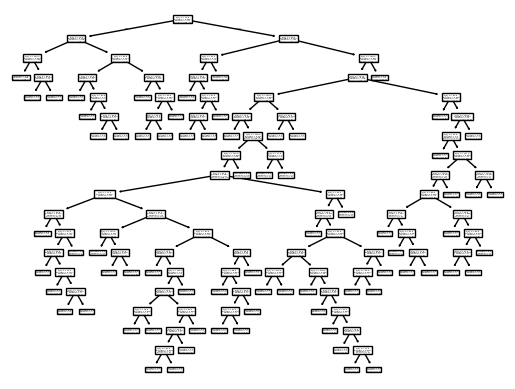

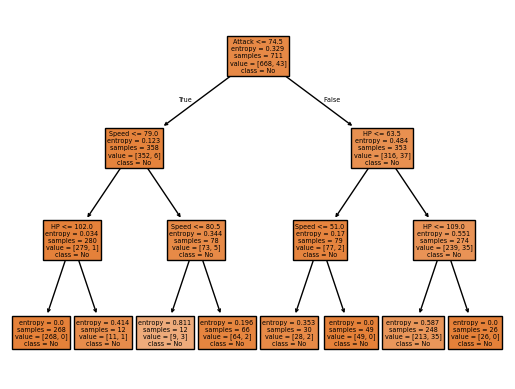

In [25]:
importances = {}
for i, col in enumerate(x.columns):
    importances[col] = model1.feature_importances_[i]
print(importances)
import matplotlib.pyplot as plt
tree.plot_tree(model1)
plt.show()
model1 = tree.DecisionTreeClassifier(criterion='entropy', max_depth=3)
model1.fit(x, y)
tree.plot_tree(model1, feature_names=x.columns, class_names=['No', 'Yes'], filled=True)
plt.show()

### Question 2: Building a Model Using a Mixed Attribute Set

#### 2.1. Data pre-processing
* Now, you will use a combination of categorical and continuous attributes to build a new classification model.
* Note: For this question, use the original dataframe (but not the X from earlier) after removing the Name and Type_2 attributes. A good idea is to re-import the data, drop the two attributes again, and continue from there.
* <b>Important:</b> 
    * As of now (v.1.3.0), scikit-learn does not support categorical attributes to be directly entered into tree-based models. To circumvent this issue, we need to convert categorical attributes into numerical form using either label or one-hot encoding. The former option is applicable for ordinal categorical attributes (i.e., A > B > C, etc.), which is not the case for our data.
    * A majority of our categorical attributes are in nominal form, therefore we will need to perform "one-hot encoding". This encoding process creates a separate attribute for each possible value in each categorical attribute and codes them using a binary (1/0) integer format.
* Create the binary attributes for the nominal categorical attributes. You can use the OneHotEncoder function from scikit-learn or Pandas' get_dummies function for this purpose. After creating the binary attributes, remove the original nominal attributes from the data.
* For dichotomous categorical attributes in the data (Yes/No) -- i.e., isLegendary and hasMegaEvolution, you can directly re-code them onto themselves using 1/0 conversion.
* Complete these operations and print out the shape of the new data set. If done correctly, you should end up with 49 columns in the data.


##### Hints:
1. <span style="color: black; background: black; span:hover { color: white}">For one-hot encoding, you can use the "get_dummies" method in Pandas or OneHotEncoder in scikit-learn.</span>
1. <span style="color: black; background: black; span:hover { color: white}">Make sure that the original nominal attributes have been removed from the data after one-hot encoding.</span>

In [29]:
df = pd.read_csv('pokemon_train.csv')
df = df.drop(columns=['Type_2'])
df = df.drop(columns=['Name'])
print(df.dtypes)
df['isLegendary'] = df['isLegendary'].map({'Yes': 1, 'No': 0})
df['hasMegaEvolution'] = df['hasMegaEvolution'].map({'Yes': 1, 'No': 0})
df = pd.get_dummies(df, columns=['Type_1', 'Color', 'Egg_Group_1'], dtype=int)
print(df.shape)

Type_1              object
HP                   int64
Attack               int64
Defense              int64
Speed                int64
isLegendary         object
Color               object
Egg_Group_1         object
hasMegaEvolution    object
dtype: object
(711, 49)


#### 2.2. Data Preparation
* Split the data into two data sets -- one containing all the input attributes and the other containing only the target attribute (hasMegaEvolution). Call the first data set X and the second one y.

##### Hints:
1. <span style="color: black; background: black; span:hover { color: white}">An easy way to copy all the attributes except the target one into a new dataframe is to make a copy of the existing data and then drop the target attribute from this copy.</span>

In [31]:
x = df.copy()
x = x.drop(columns=['hasMegaEvolution'])
y = df['hasMegaEvolution']
print(x.shape)
print(y.unique())

(711, 48)
[0 1]


#### 2.3. Building and observing the model
* Build a decision tree model using the new data sets. You are free to tinker with parameters, etc.
* Use feature\_importances_ attribute to obtain the normalized feature weights for the new model.

{'HP': np.float64(0.0782206223222849), 'Attack': np.float64(0.4585041141243834), 'Defense': np.float64(0.0), 'Speed': np.float64(0.295285274102726), 'isLegendary': np.float64(0.0), 'Type_1_Bug': np.float64(0.0), 'Type_1_Dark': np.float64(0.0), 'Type_1_Dragon': np.float64(0.0), 'Type_1_Electric': np.float64(0.0), 'Type_1_Fairy': np.float64(0.0), 'Type_1_Fighting': np.float64(0.0), 'Type_1_Fire': np.float64(0.0), 'Type_1_Flying': np.float64(0.0), 'Type_1_Ghost': np.float64(0.0), 'Type_1_Grass': np.float64(0.0), 'Type_1_Ground': np.float64(0.0), 'Type_1_Ice': np.float64(0.0), 'Type_1_Normal': np.float64(0.0), 'Type_1_Poison': np.float64(0.0), 'Type_1_Psychic': np.float64(0.0), 'Type_1_Rock': np.float64(0.0), 'Type_1_Steel': np.float64(0.0), 'Type_1_Water': np.float64(0.0), 'Color_Black': np.float64(0.0), 'Color_Blue': np.float64(0.0), 'Color_Brown': np.float64(0.0), 'Color_Green': np.float64(0.0), 'Color_Grey': np.float64(0.0), 'Color_Pink': np.float64(0.0), 'Color_Purple': np.float64(0.0

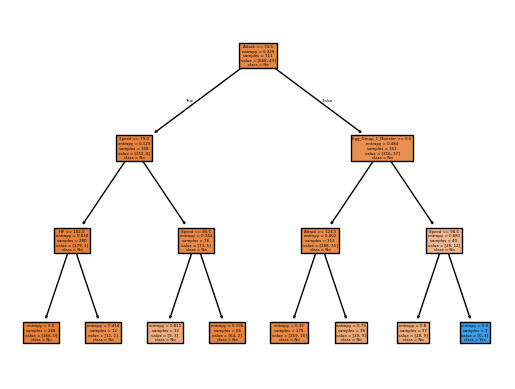

In [38]:
model2 = tree.DecisionTreeClassifier(criterion='entropy', max_depth=3)
model2.fit(x, y)
importances2 = {}
for i, col in enumerate(x.columns):
    importances2[col] = model2.feature_importances_[i]
print(importances2)
tree.plot_tree(model2, feature_names=x.columns, class_names=['No', 'Yes'], filled=True)
plt.show()

### Question 3: Building and Applying the Model on to a Prediction Dataset
* For this question, your task is to predict the "hasMegaEvolution" values for a set of observations with missing target attribute values. These new observations are in a dataset named "pokemon_predict.csv". 
* The goal is to build a model from the "pokemon_train.csv" dataset and apply that on the "pokemon_predict.csv" dataset. Application of a model is easy -- all you need to do is to call the "predict" method in the model object and pass the prediction dataset into the method. However, if you try doing this as is, you will encounter errors.
* The problem is that when applying a trained Scikit-Learn model to new prediction data, the prediction dataset must have the exact same features (columns) in the exact same order as the training set. However, applying one-hot encoding on the prediction data (e.g., by using pd.get_dummies) will generate fewer columns because the prediction set only contains a small subset of categorical values compared to the training set. Alternatively, it's also possible that the prediction data set may include values that have not occurred in the training data.
* To solve these issues, a good approach is to use the .reindex() method. Accordingly, prepare the prediction data as follows:
1) Import the data and remove the Name and Type_2 attributes as well as the target attribute, "hasMegaEvolution".
2) Convert the binary attribute, 'isLegendary', into 1/0.
3) One-hot encode nominal attributes using pd.get_dummies()
4) Reindex columns by running: X_predict = X_predict.reindex(columns=X_train.columns, fill_value=0). This step automatically adds missing training columns filled with 0, drops any extra unseen columns, and forces the column ordering to match X_train exactly.
* After preparing the prediction data, call the predict() method on the training model by passing the X_prediction data set as an input and obtain the prediction results. The predict method should create a 1d array output.
* If there are any predicted "1" values (i.e., mega evolving pokemons), provide their names. You need to link the predicted array indices back to the original prediction data to obtain the names.

In [39]:
predict_df = pd.read_csv('pokemon_predict.csv')
predict_names = predict_df['Name']
x_predict = predict_df.drop(columns=['Name', 'Type_2', 'hasMegaEvolution'])
x_predict['isLegendary'] = x_predict['isLegendary'].map({'Yes': 1, 'No': 0})
x_predict = pd.get_dummies(x_predict, columns=['Type_1', 'Color', 'Egg_Group_1'], dtype=int)
x_predict = x_predict.reindex(columns=x.columns, fill_value=0)
print(x_predict.shape)
print(x.shape)
predictions = model2.predict(x_predict)
print(predictions)
predict_names = predict_names.reset_index(drop=True)
predictions_series = pd.Series(predictions)
mega_mask = predictions_series == 1
mega_names = predict_names[mega_mask]
print(mega_names)

(9, 48)
(711, 48)
[0 0 0 0 0 0 0 0 0]
Series([], Name: Name, dtype: object)
